## Grouped Titles Dimensionality Reduction

Using includes method with keywords may be powerful to help reduce number of unique job titles without us having to do manual mappings. Can also use key phrases here. just investigating to see if any common words/phrases arise to help us do further grouping.

In [2]:
import os
os.getcwd()
#os.chdir("/Users/ellawileman/Documents/spring2025/dsci2/dsci2_final_project")

'/Users/rmclatcher/Desktop/DataSci/FinalProject/dsci2_final_project'

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
#jobs = pd.read_csv("fake_job_postings.csv")
jobs = pd.read_csv("jobs_clean.csv")

In [4]:
vals = jobs["Grouped_Titles"].value_counts()
vals

Grouped_Titles
English Teacher Abroad                                         490
Customer Service Associate                                     198
Software Engineering                                           155
Graduates: English Teacher Abroad (Conversational)             144
Customer Service Associate - Part Time                          91
                                                              ... 
Prop Stylist (Temporary position: Nov '13 - Feb '14)             1
Sales Executive - Office Equipment                               1
QA/QC Leader - Cured Meats Co - Chicagoland                      1
Application Developer/SQL Server                                 1
Project Cost Control Staff Engineer - Cost Control Exp - TX      1
Name: count, Length: 10909, dtype: int64

In [5]:
most_common = vals[vals > 25]
len(most_common)

35

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34],
 [Text(0, 0, 'English Teacher Abroad'),
  Text(1, 0, 'Customer Service Associate'),
  Text(2, 0, 'Software Engineering'),
  Text(3, 0, 'Graduates: English Teacher Abroad (Conversational)'),
  Text(4, 0, 'Customer Service Associate - Part Time'),
  Text(5, 0, 'Account Manager'),
  Text(6, 0, 'Project Manager'),
  Text(7, 0, 'Web Developer'),
  Text(8, 0, 'Customer Service Representative'),
  Text(9, 0, 'Beauty & Fragrance consultants needed'),
  Text(10, 0, 'Graduates: English Teacher Abroad'),
  Text(11, 0, 'Administrative Assistant'),
  Text(12, 0, 'Sales Representative'),
  Text(13, 0, 'Product Manager'),
  Text(14, 0, 'Customer Service Team Lead'),
  Text(15, 0, 'Account Executive'),
  Text(16, 0, 'Marketing Manager'),
  Text(17, 0, 'Office Manager'),
  Text(18, 0, 'Senior Software Eng

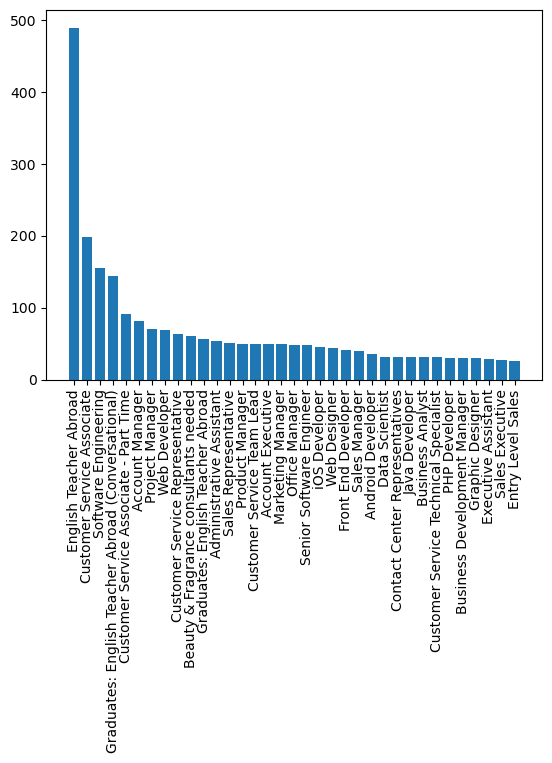

In [6]:
plt.bar(most_common.index, most_common.values)
plt.xticks(rotation=90)

In [7]:
#most_common

In [8]:
from collections import Counter
from nltk.corpus import stopwords
import pandas as pd

# Assuming 'Grouped_Titles' is the column of interest
grouped_titles = jobs['Grouped_Titles'].fillna('')  # Replace NaN with empty strings

stop_words = set(stopwords.words('english'))  # Set of common stopwords
# Tokenize the text and count word frequencies
all_words = ' '.join(grouped_titles).split()  # Combine all titles and split into words
filtered_words = [word for word in all_words if word.isalpha() and word.lower() not in stop_words]  # Filter
word_counts = Counter(filtered_words)  # Count occurrences of each word

# Get the most common keywords
most_common_keywords = word_counts.most_common(50)  # Top 20 most common words

# Display the results
print("Most Common Keywords in Grouped_Titles:")
for word, count in most_common_keywords:
    print(f"{word}: {count}")

ModuleNotFoundError: No module named 'nltk'

# Most Common 2 word phrases

Can also look at most common phrases in Grouped_Titles (like 2 words together)

In [182]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Assuming 'Grouped_Titles' is the column of interest
grouped_titles = jobs['Grouped_Titles'].fillna('')  # Replace NaN with empty strings
# Preprocess the text inline
grouped_titles = grouped_titles.str.replace(r'\d+', '', regex=True)  # Remove numbers
grouped_titles = grouped_titles.str.replace(r'\byear olds?\b', '', regex=True, case=False)  # Remove "year olds"


# Use CountVectorizer to extract bigrams (2-word phrases)
vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english')
bigrams = vectorizer.fit_transform(grouped_titles)

# Sum the occurrences of each bigram
bigram_counts = bigrams.sum(axis=0)
bigram_frequencies = [(phrase, bigram_counts[0, idx]) for phrase, idx in vectorizer.vocabulary_.items()]
bigram_frequencies = sorted(bigram_frequencies, key=lambda x: x[1], reverse=True)

# Display the top 20 most common bigrams
print("Top 50 Most Common 2-Word Phrases in Grouped_Titles:")
for phrase, count in bigram_frequencies[:100]:
    print(f"{phrase}: {count}")

Top 50 Most Common 2-Word Phrases in Grouped_Titles:
customer service: 741
english teacher: 720
teacher abroad: 691
service associate: 343
software engineer: 304
web developer: 265
sales representative: 231
account manager: 231
project manager: 219
business development: 211
graduates english: 204
account executive: 187
marketing manager: 170
software engineering: 164
end developer: 163
sales manager: 151
abroad conversational: 145
product manager: 129
data entry: 129
inside sales: 128
apprenticeship nas: 124
associate time: 107
entry level: 107
administrative assistant: 104
senior software: 104
ux designer: 102
sales executive: 100
java developer: 97
office manager: 97
ios developer: 92
social media: 91
net developer: 87
service representative: 87
php developer: 87
web designer: 86
business analyst: 81
team lead: 80
sales professional: 78
development manager: 78
application developer: 77
software developer: 77
fragrance consultants: 73
business admin: 72
consultants needed: 72
ui ux: 7

Now could use "includes" methods with these words to further filter down, and include only above a certain count (threshold), would want to ignore case most likely

Would want to group keywords: developer, ui, ux, software, web, java

With this smaller number of groups, it becomes easier to map common job titles into more general career paths or specific buzzwords. Some of these two word phrases look meaningful!
    Ex: sales associate, entry level, product manager, sales rep, social media, quality assurance etc. 
    Or we can just group based on "manager" as a whole etc. May yield less groups. Need to weigh the trade off in potentially losing some detail vs. looking into general patterns. Note that not every listing may be perfectly classified. I like your idea of introducing an "other" category. This has just been some general exploration, nothing is set in stone!

In [1]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
from nltk.corpus import stopwords
import string
default_stopwords = set(stopwords.words('english'))
# Assuming 'Grouped_Titles' is the column of interest
grouped_titles = jobs['Grouped_Titles'].fillna('')  # Replace NaN with empty strings
one_letter_words = set(string.ascii_lowercase)  # a, b, c, ..., z

# Combine the default stopwords with one-letter and two-letter words
extended_stopwords = default_stopwords.union(one_letter_words)
extended_stopwords = list(extended_stopwords)


# Preprocess the text
grouped_titles = grouped_titles.str.replace(r'\d+', '', regex=True)  # Remove numbers
grouped_titles = grouped_titles.str.replace(r'\byear olds?\b', '', regex=True, case=False)  # Remove "year olds"
grouped_titles = grouped_titles.str.replace(r'[^a-zA-Z\s]', '', regex=True)  # Remove non-alphabetic characters

# Adjustable thresholds
BIGRAM_THRESHOLD = 200  # Increase the number of top bigrams
UNIGRAM_THRESHOLD = 200  # Increase the number of top unigrams

# Step 1: Extract Bigrams
vectorizer_bigrams = CountVectorizer(ngram_range=(2, 2), stop_words=extended_stopwords, token_pattern=r'\b[a-zA-Z]+\b')
bigrams = vectorizer_bigrams.fit_transform(grouped_titles)

# Get the top bigrams
bigram_counts = bigrams.sum(axis=0)
bigram_frequencies = [(phrase, bigram_counts[0, idx]) for phrase, idx in vectorizer_bigrams.vocabulary_.items()]
bigram_frequencies = sorted(bigram_frequencies, key=lambda x: x[1], reverse=True)
top_bigrams = [phrase for phrase, count in bigram_frequencies[:BIGRAM_THRESHOLD]]

# Step 2: Extract Unigrams
vectorizer_unigrams = CountVectorizer(ngram_range=(1, 1), stop_words=extended_stopwords, token_pattern=r'\b[a-zA-Z]+\b')
unigrams = vectorizer_unigrams.fit_transform(grouped_titles)

# Get the top unigrams
unigram_counts = unigrams.sum(axis=0)
unigram_frequencies = [(word, unigram_counts[0, idx]) for word, idx in vectorizer_unigrams.vocabulary_.items()]
unigram_frequencies = sorted(unigram_frequencies, key=lambda x: x[1], reverse=True)
top_unigrams = [word for word, count in unigram_frequencies[:UNIGRAM_THRESHOLD]]

def map_to_bigram_or_unigram(title):
    # Check for specific bigrams first
    for bigram in top_bigrams:
        if bigram in title.lower():
            return bigram
    # Fallback to generic unigrams
    for unigram in top_unigrams:
        if unigram in title.lower():
            return unigram
    return "Other"


# Step 5: Apply the Mapping
jobs['Mapped_Title'] = grouped_titles.apply(lambda title: map_to_bigram(title) or map_to_unigram(title))

# Analyze the distribution of groups
group_distribution = jobs['Mapped_Title'].value_counts()
print(group_distribution)

# Display the percentage of "Other"
percent_other = (group_distribution['Other'] / len(jobs)) * 100
print(f"Percentage of 'Other': {percent_other:.2f}%")

# don't want too many titles to be placed into other (loss of detail/info)

print(jobs['Mapped_Title'])

ModuleNotFoundError: No module named 'nltk'

In [184]:
jobs["Mapped_Title"].value_counts()

Mapped_Title
manager               761
customer service      750
english teacher       721
Other                 696
engineer              628
                     ... 
rails                   1
beauty promotional      1
experience              1
insurance               1
entry clerk             1
Name: count, Length: 323, dtype: int64

In [186]:
# now want to group very low frequency titles into "Other"
MIN_FREQUENCY = 30  # Set the minimum frequency threshold

# Get the frequency of each label
label_frequencies = jobs['Mapped_Title'].value_counts()

# Identify labels below the threshold
low_frequency_labels = label_frequencies[label_frequencies < MIN_FREQUENCY].index

# Reassign low-frequency labels to "Other"
jobs['Mapped_Title'] = jobs['Mapped_Title'].apply(lambda x: "Other" if x in low_frequency_labels else x)

# Reanalyze the distribution of groups
group_distribution = jobs['Mapped_Title'].value_counts()

# Display the updated percentage of "Other"
percent_other = (group_distribution['Other'] / len(jobs)) * 100
print(f"Updated Percentage of 'Other': {percent_other:.2f}%")

display(group_distribution)

Updated Percentage of 'Other': 16.68%


Mapped_Title
Other                     2982
manager                    761
customer service           750
english teacher            721
engineer                   628
                          ... 
recruitment consultant      30
technical                   30
junior                      30
frontend engineer           30
title closer                30
Name: count, Length: 145, dtype: int64

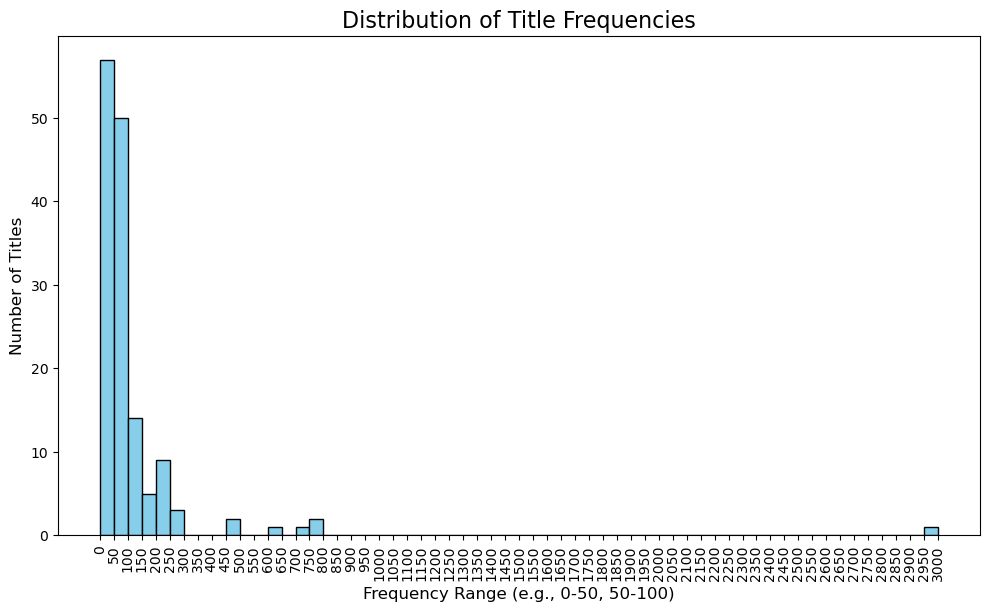

In [190]:
import matplotlib.pyplot as plt

# Get the frequency of each title
title_frequencies = jobs['Mapped_Title'].value_counts()

# Plot a histogram of the frequencies
plt.figure(figsize=(10, 6))
plt.hist(title_frequencies, bins=range(0, title_frequencies.max() + 50, 50), color='skyblue', edgecolor='black')

# Add labels and title
plt.title("Distribution of Title Frequencies", fontsize=16)
plt.xlabel("Frequency Range (e.g., 0-50, 50-100)", fontsize=12)
plt.ylabel("Number of Titles", fontsize=12)
plt.xticks(range(0, title_frequencies.max() + 50, 50))  # Set x-axis ticks
plt.tight_layout()
plt.xticks(rotation=90)

# Show the plot
plt.show()

Can we also group region further to reduce cardinality 